## Week 11 Exercises

###<font color=green> Replace the name below with **your name**. For full credit, your total needs to add up to 100 points.

I highly recommend reading the accompanying pdf for programming notes and other important details.

# Kavin Kannan

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi,sin,cos,exp,real,imag
import scipy

1. Electrostatic Boundary Value Problems: the Laplace equation

(a) (15 points) Write a working program that uses the Gauss-Seidel
method with overrelaxation) method (see Programming Notes on
the next page) to solve the Laplace equation:

∂
2V (x, y)
∂x2
+
∂
2V (x, y)
∂y2
= 0

in the square domain 0 < x < L, 0 < y < L. We will begin with
boundary conditions V = 0 on the top and bottom edges of the
square, and V = 100 V on the left and right edges.
Iterate until V (x, y) at every grid point changes by no more than
(δV )max, a parameter you can set (Test your code using (δV )max =
10−4, and then use 10−6
). Generate a well-labeled density plot of
V (x, y) using plt.imshow, and print out the number of iterations
required afor convergence. Remember to use the origin = lower
and extent=(xmin,xmax,ymin,ymax) options in plt.imshow to
define the right axis ranges.
You should find V (x, y) ≈ 50 V at the center of the square – check
this explicitly by printing out the value at x = y = L/2.

(b) (5 points) Generate a density plot of V (x, y) for a different set of
boundary conditions: V = 100 V on adjacent sides of the square,
and V = 0 on the two remaining sides.

Sweeps = 694    Biggest dV = 9.84749220123149e-07 V
Center voltage = 49.999959446516435 V


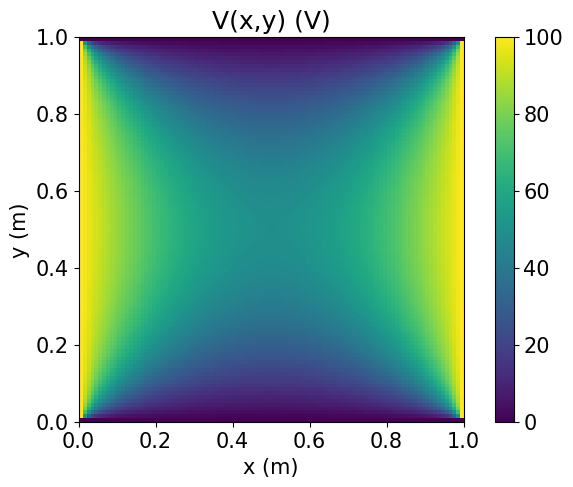

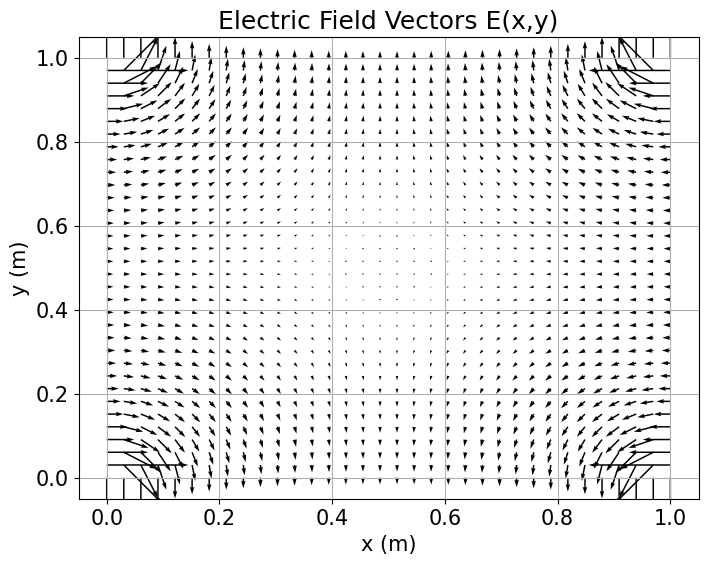

In [43]:
ll = 1.0     # size of square (m)
nn = 100      # grid pts on each edge
tolerance = 1e-6 # tolerance level: stop when change in V is less than this
omega = 0.9     # over relaxation parameter

a = ll/(nn-1)           # grid spacing (m), needed for Poisson equation
phi = np.zeros((nn,nn))  #  will hold V(x,y) (V)

# set V on boundaries
for j in range(nn):
    phi[j,0] = 100.0      # left edge
    phi[j,nn-1] = 100.0   # right edge
for k in range(nn):
    phi[0,k] = 0.0     # bottom edge
    phi[nn-1,k] = 0.0   # top edge

# relaxation calculation
deltaphimax = 2*tolerance  # will hold running value of biggest Delta-V, set large so calc will start
sweeps = 0      # keep track of number of iterations before convergence
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0    
    for j in range(1,nn-1):
        for k in range(1,nn-1):
            phinew = 0.25*(phi[j+1,k]+phi[j-1,k]+phi[j,k+1]+phi[j,k-1]) #relaxation
            deltaphi = (1+omega)*(phinew - phi[j,k])  # over-relaxation correction
            phi[j,k] += deltaphi       # add difference to old value
            if abs(deltaphi)>deltaphimax:     # store largest difference in dvvbig
                deltaphimax = abs(deltaphi)   # only change this value when the deltaV exceeds current maximum

print('Sweeps =',sweeps,'   Biggest dV =',deltaphimax,'V')
print(f'Center voltage = {phi[int(nn/2), int(nn/2)]} V')

# plot result
plt.rc('font',size=15)
plt.figure(figsize=(8,5))
plt.imshow(phi,origin='lower',extent=(0,ll,0,ll))
plt.colorbar()
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('V(x,y) (V)')
plt.show()

Ex = np.zeros_like(phi)
Ey = np.zeros_like(phi)

eex = np.zeros((nn,nn))
eey = np.zeros((nn,nn)) # arrays to hold field components
for j in range(nn):
    for k in range(nn):
        if k==0:
            eex[j,k] = -(phi[j,k+1] - phi[j,k])/a
        elif k==nn-1:
            eex[j,k] = -(phi[j,k] - phi[j,k-1])/a
        else:
            eex[j,k] = -(phi[j,k+1] - phi[j,k-1])/(2*a)
        if j==0:
            eey[j,k] = -(phi[j+1,k] - phi[j,k])/a
        elif j==nn-1:
            eey[j,k] = -(phi[j,k] - phi[j-1,k])/a
        else:
            eey[j,k] = -(phi[j+1,k] - phi[j-1,k])/(2*a)
        

# Plotting
X = np.linspace(0, ll, nn)
Y = np.linspace(0, ll, nn)
X, Y = np.meshgrid(X, Y)

dec = 3 # decimation factor
EX2 = eex[::dec,::dec]
EY2 = eey[::dec,::dec]
X2 = X[::dec,::dec]
Y2 = Y[::dec,::dec]

plt.rc('font', size=15)
plt.figure(figsize=(8,6))
plt.quiver(X2,Y2,EX2,EY2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Electric Field Vectors E(x,y)')
plt.grid(True)
plt.show()

Sweeps = 664    Biggest dV = 9.795614957397447e-07 V
Center voltage = 49.15702998684196 V


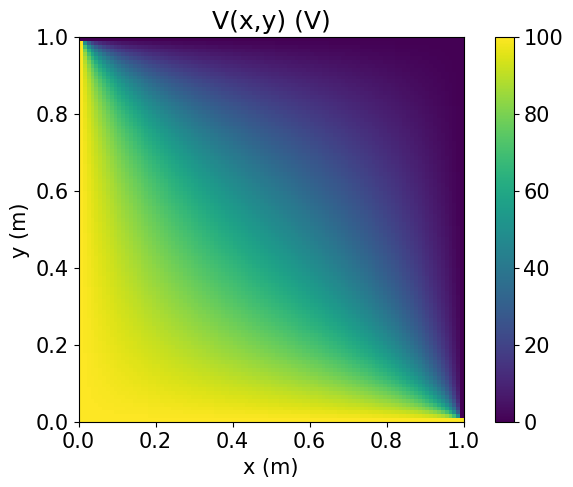

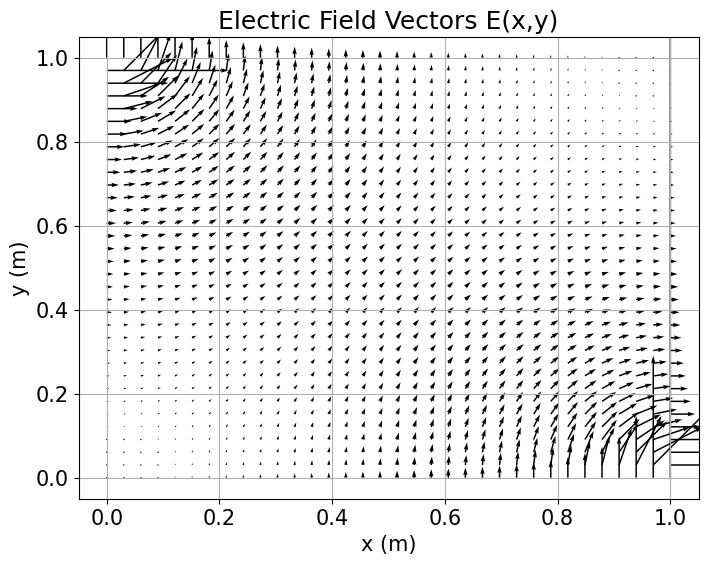

In [44]:
ll = 1.0     # size of square (m)
nn = 100      # grid pts on each edge
tolerance = 1e-6 # tolerance level: stop when change in V is less than this
omega = 0.9     # over relaxation parameter

a = ll/(nn-1)           # grid spacing (m), needed for Poisson equation
phi = np.zeros((nn,nn))  #  will hold V(x,y) (V)

# set V on boundaries
for j in range(nn):
    phi[j,0] = 100.0      # left edge
    phi[j,nn-1] = 0.0   # right edge
for k in range(nn):
    phi[0,k] = 100.0     # bottom edge
    phi[nn-1,k] = 0.0   # top edge

# relaxation calculation
deltaphimax = 2*tolerance  # will hold running value of biggest Delta-V, set large so calc will start
sweeps = 0      # keep track of number of iterations before convergence
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0    
    for j in range(1,nn-1):
        for k in range(1,nn-1):
            phinew = 0.25*(phi[j+1,k]+phi[j-1,k]+phi[j,k+1]+phi[j,k-1]) #relaxation
            deltaphi = (1+omega)*(phinew - phi[j,k])  # over-relaxation correction
            phi[j,k] += deltaphi       # add difference to old value
            if abs(deltaphi)>deltaphimax:     # store largest difference in dvvbig
                deltaphimax = abs(deltaphi)   # only change this value when the deltaV exceeds current maximum

print('Sweeps =',sweeps,'   Biggest dV =',deltaphimax,'V')
print(f'Center voltage = {phi[int(nn/2), int(nn/2)]} V')

# plot result
plt.rc('font',size=15)
plt.figure(figsize=(8,5))
plt.imshow(phi,origin='lower',extent=(0,ll,0,ll))
plt.colorbar()
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('V(x,y) (V)')
plt.show()

eex = np.zeros((nn,nn))
eey = np.zeros((nn,nn)) # arrays to hold field components
for j in range(nn):
    for k in range(nn):
        if k==0:
            eex[j,k] = -(phi[j,k+1] - phi[j,k])/a
        elif k==nn-1:
            eex[j,k] = -(phi[j,k] - phi[j,k-1])/a
        else:
            eex[j,k] = -(phi[j,k+1] - phi[j,k-1])/(2*a)
        if j==0:
            eey[j,k] = -(phi[j+1,k] - phi[j,k])/a
        elif j==nn-1:
            eey[j,k] = -(phi[j,k] - phi[j-1,k])/a
        else:
            eey[j,k] = -(phi[j+1,k] - phi[j-1,k])/(2*a)
        

# Plotting
X = np.linspace(0, ll, nn)
Y = np.linspace(0, ll, nn)
X, Y = np.meshgrid(X, Y)

dec = 3 # decimation factor
EX2 = eex[::dec,::dec]
EY2 = eey[::dec,::dec]
X2 = X[::dec,::dec]
Y2 = Y[::dec,::dec]

plt.rc('font', size=15)
plt.figure(figsize=(8,6))
plt.quiver(X2,Y2,EX2,EY2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Electric Field Vectors E(x,y)')
plt.grid(True)
plt.show()

2. Poisson Equation: finite charge density (15 points) Add a finite
charge density (ρ 6= 0) in a region in the center of the square:

ρ(x, y) = 
ρ0 if L
3 < x < 2L
3
,
L
3 < y < 2L
3

0 otherwise.
This involves solving the Poisson equation:

∂
2V (x, y)
∂x2
+
∂
2V (x, y)
∂y2
= −
ρ(x, y)
0

You need ρ0 large enough to show up clearly on your plot, trying both
positive and negative charges. Try ρ0/0 = ±106 V/m2

. Note also that
the above inequality applies in both x and y directions, i.e. the charge
density is centered on the square and symmetric in x and y.

Sweeps = 947    Biggest dV = 9.813884389586747e-07 V
Center voltage = 27241.397769427957 V


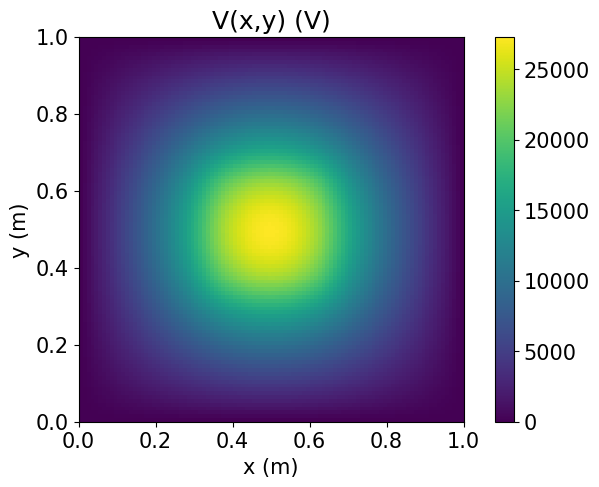

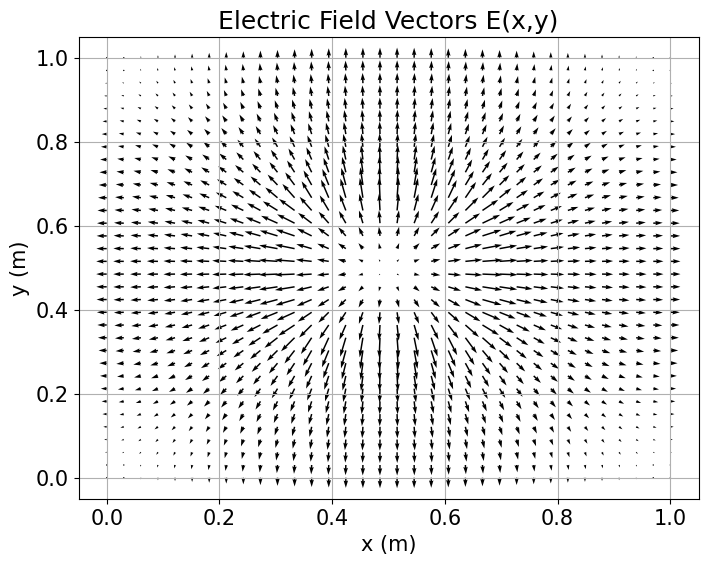

In [42]:
ll = 1.0     # size of square (m)
nn = 100      # grid pts on each edge
tolerance = 1e-6 # tolerance level: stop when change in V is less than this
omega = 0.9     # over relaxation parameter

a = ll/(nn-1)           # grid spacing (m)
phi = np.zeros((nn,nn))  # will hold V(x,y) (V)

rho0 = 1e6  
rho = np.zeros((nn, nn))

# Set rho(x,y) in center region
for i in range(nn):
    for j in range(nn):
        x = i * a
        y = j * a
        if ll/3 < x < 2*ll/3 and ll/3 < y < 2*ll/3:
            rho[i,j] = rho0

# set V on boundaries
for i in range(nn):
    phi[i,0] = 0.0      # left edge
    phi[i,nn-1] = 0.0     # right edge
for j in range(nn):
    phi[0,j] = 0.0      # bottom edge
    phi[nn-1,j] = 0.0     # top edge

# relaxation calculation
deltaphimax = 2*tolerance  
sweeps = 0      
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0    
    for j in range(1,nn-1):
        for k in range(1,nn-1):
            # Include rho[j,k] term for Poisson equation
            phinew = 0.25*(phi[j+1,k] + phi[j-1,k] + phi[j,k+1] + phi[j,k-1] + a*a*rho[j,k])
            deltaphi = (1+omega)*(phinew - phi[j,k])  
            phi[j,k] += deltaphi       
            if abs(deltaphi) > deltaphimax:     
                deltaphimax = abs(deltaphi)   

print('Sweeps =', sweeps, '   Biggest dV =', deltaphimax, 'V')
print(f'Center voltage = {phi[nn//2, nn//2]} V')

# plot result
plt.rc('font',size=15)
plt.figure(figsize=(8,5))
plt.imshow(phi,origin='lower',extent=(0,ll,0,ll))
plt.colorbar()
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('V(x,y) (V)')
plt.show()

Ex = np.zeros_like(phi)
Ey = np.zeros_like(phi)

eex = np.zeros((nn,nn))
eey = np.zeros((nn,nn)) # arrays to hold field components
for j in range(nn):
    for k in range(nn):
        if k==0:
            eex[j,k] = -(phi[j,k+1] - phi[j,k])/a
        elif k==nn-1:
            eex[j,k] = -(phi[j,k] - phi[j,k-1])/a
        else:
            eex[j,k] = -(phi[j,k+1] - phi[j,k-1])/(2*a)
        if j==0:
            eey[j,k] = -(phi[j+1,k] - phi[j,k])/a
        elif j==nn-1:
            eey[j,k] = -(phi[j,k] - phi[j-1,k])/a
        else:
            eey[j,k] = -(phi[j+1,k] - phi[j-1,k])/(2*a)
        

# Plotting
X = np.linspace(0, ll, nn)
Y = np.linspace(0, ll, nn)
X, Y = np.meshgrid(X, Y)

dec = 3 # decimation factor
EX2 = eex[::dec,::dec]
EY2 = eey[::dec,::dec]
X2 = X[::dec,::dec]
Y2 = Y[::dec,::dec]

plt.rc('font', size=15)
plt.figure(figsize=(8,6))
plt.quiver(X2,Y2,EX2,EY2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Electric Field Vectors E(x,y)')
plt.grid(True)
plt.show()

3. Plotting equipotentials. The previous problems covered solving the
Laplace/Poisson equations using the Gauss-Seidel method. Use your
version of the Laplace/Poisson PDE solver as a starting point to create
code that plots the equipotential curves for V (x, y) inside the square
with specified boundary conditions and charge density. These are the
curves of constant V . An example is shown on the left of Fig. 1 for the
boundary conditions V = +100 V on the left and right edges of the
squares and zero on the top and bottom edges.
Generate equipotential plots for the following boundary conditions:

(a) (10 points) V = 0 on the top and bottom edges of the square, and
V = 100 V on the left and right edges.

(b) (5 points) Same V on adjacent edges e.g. V = 100 V on left and
top, zero on other two sides.

(c) (10 points) The case in Prob 2, the centered square of charge:

ρ(x, y) = 
ρ0 if L
3 < x < 2L
3
,
L
3 < y < 2L
3
,
0 otherwise 

with ρ0/0 = ±106 V/m2
.

Sweeps = 694    Biggest dV = 9.84749220123149e-07 V
Center voltage = 49.999959446516435 V


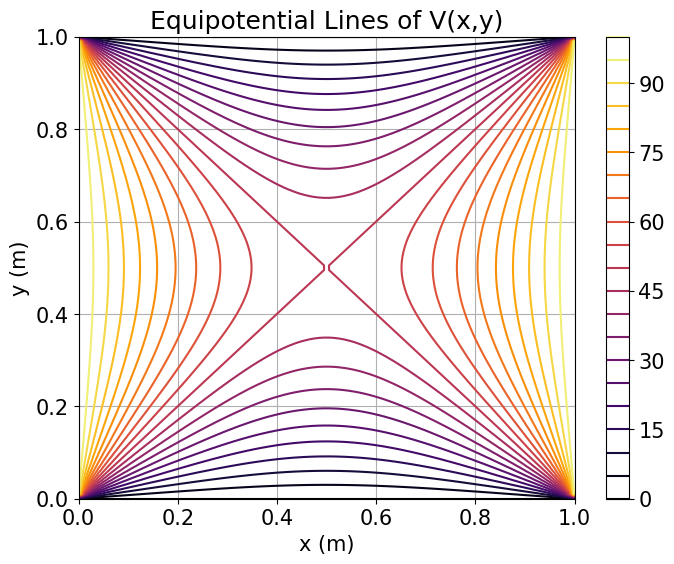

In [13]:
ll = 1.0     # size of square (m)
nn = 100      # grid pts on each edge
tolerance = 1e-6 # tolerance level: stop when change in V is less than this
omega = 0.9     # over relaxation parameter

a = ll/(nn-1)           # grid spacing (m), needed for Poisson equation
phi = np.zeros((nn,nn))  #  will hold V(x,y) (V)

# set V on boundaries
for j in range(nn):
    phi[j,0] = 100.0      # left edge
    phi[j,nn-1] = 100.0   # right edge
for k in range(nn):
    phi[0,k] = 0.0     # bottom edge
    phi[nn-1,k] = 0.0   # top edge

# relaxation calculation
deltaphimax = 2*tolerance  # will hold running value of biggest Delta-V, set large so calc will start
sweeps = 0      # keep track of number of iterations before convergence
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0    
    for j in range(1,nn-1):
        for k in range(1,nn-1):
            phinew = 0.25*(phi[j+1,k]+phi[j-1,k]+phi[j,k+1]+phi[j,k-1]) #relaxation
            deltaphi = (1+omega)*(phinew - phi[j,k])  # over-relaxation correction
            phi[j,k] += deltaphi       # add difference to old value
            if abs(deltaphi)>deltaphimax:     # store largest difference in dvvbig
                deltaphimax = abs(deltaphi)   # only change this value when the deltaV exceeds current maximum

print('Sweeps =',sweeps,'   Biggest dV =',deltaphimax,'V')
print(f'Center voltage = {phi[int(nn/2), int(nn/2)]} V')

# Contour plot
plt.rc('font', size=15)
plt.figure(figsize=(8,6))

X = np.linspace(0, ll, nn)
Y = np.linspace(0, ll, nn)
X, Y = np.meshgrid(X, Y)

cp = plt.contour(X, Y, phi, levels=20, cmap='inferno')
plt.colorbar(cp)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Equipotential Lines of V(x,y)')
plt.grid(True)
plt.show()

Sweeps = 664    Biggest dV = 9.795614957397447e-07 V
Center voltage = 49.15702998684196 V


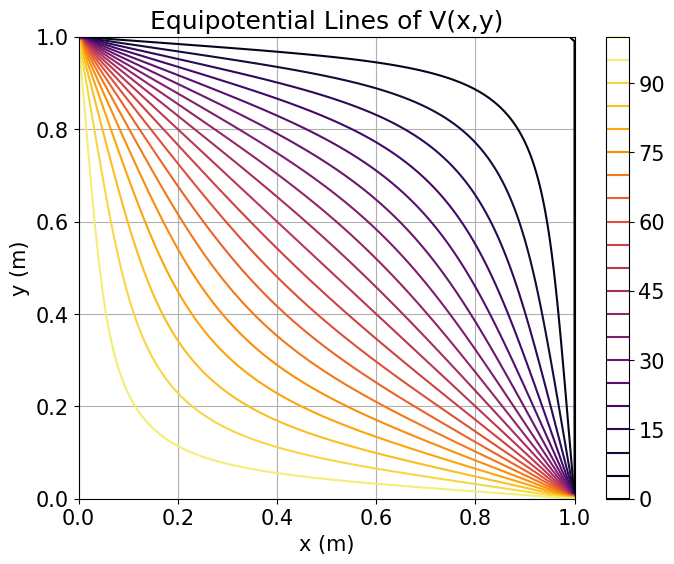

In [ ]:
ll = 1.0     # size of square (m)
nn = 100      # grid pts on each edge
tolerance = 1e-6 # tolerance level: stop when change in V is less than this
omega = 0.9     # over relaxation parameter

a = ll/(nn-1)           # grid spacing (m), needed for Poisson equation
phi = np.zeros((nn,nn))  #  will hold V(x,y) (V)

# set V on boundaries
for j in range(nn):
    phi[j,0] = 100.0      # left edge
    phi[j,nn-1] = 0.0   # right edge
for k in range(nn):
    phi[0,k] = 100.0     # bottom edge
    phi[nn-1,k] = 0.0   # top edge

# relaxation calculation
deltaphimax = 2*tolerance  # will hold running value of biggest Delta-V, set large so calc will start
sweeps = 0      # keep track of number of iterations before convergence
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0    
    for j in range(1,nn-1):
        for k in range(1,nn-1):
            phinew = 0.25*(phi[j+1,k]+phi[j-1,k]+phi[j,k+1]+phi[j,k-1]) #relaxation
            deltaphi = (1+omega)*(phinew - phi[j,k])  # over-relaxation correction
            phi[j,k] += deltaphi       # add difference to old value
            if abs(deltaphi)>deltaphimax:     # store largest difference in dvvbig
                deltaphimax = abs(deltaphi)   # only change this value when the deltaV exceeds current maximum

print('Sweeps =',sweeps,'   Biggest dV =',deltaphimax,'V')
print(f'Center voltage = {phi[int(nn/2), int(nn/2)]} V')

# Contour plot
plt.rc('font', size=15)
plt.figure(figsize=(8,6))

X = np.linspace(0, ll, nn)
Y = np.linspace(0, ll, nn)
X, Y = np.meshgrid(X, Y)

cp = plt.contour(X, Y, phi, levels=20, cmap='inferno')
plt.colorbar(cp)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Equipotential Lines of V(x,y)')
plt.grid(True)
plt.show()

Sweeps = 947    Biggest dV = 9.813884389586747e-07 V
Center voltage = 27241.397769427957 V


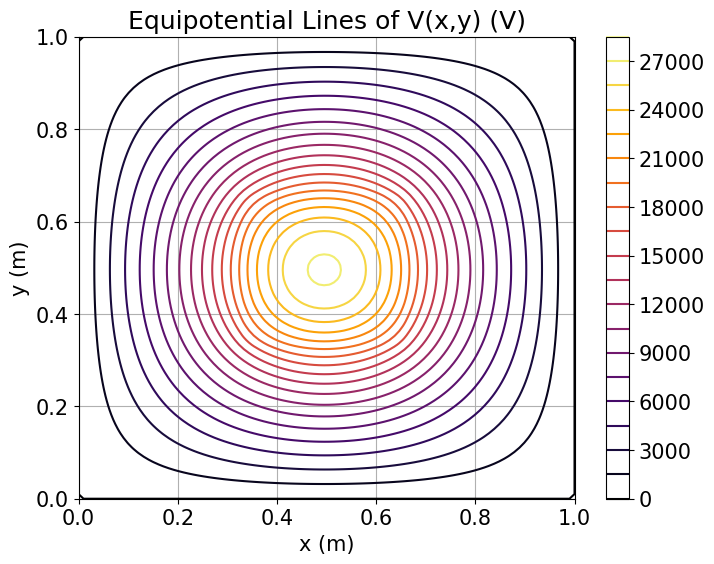

In [ ]:
ll = 1.0     # size of square (m)
nn = 100      # grid pts on each edge
tolerance = 1e-6 # tolerance level: stop when change in V is less than this
omega = 0.9     # over relaxation parameter

a = ll/(nn-1)           # grid spacing (m)
phi = np.zeros((nn,nn))  # will hold V(x,y) (V)

rho0 = 1e6  
rho = np.zeros((nn, nn))

# Set 
for i in range(nn):
    for j in range(nn):
        x = i * a
        y = j * a
        if ll/3 < x < 2*ll/3 and ll/3 < y < 2*ll/3:
            rho[i,j] = rho0

# set V on boundaries
for i in range(nn):
    phi[i,0] = 0.0      # left edge
    phi[i,nn-1] = 0.0     # right edge
for j in range(nn):
    phi[0,j] = 0.0      # bottom edge
    phi[nn-1,j] = 0.0     # top edge

# relaxation calculation
deltaphimax = 2*tolerance  
sweeps = 0      
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0    
    for j in range(1,nn-1):
        for k in range(1,nn-1):
            phinew = 0.25*(phi[j+1,k] + phi[j-1,k] + phi[j,k+1] + phi[j,k-1] + a*a*rho[j,k])
            deltaphi = (1+omega)*(phinew - phi[j,k])  
            phi[j,k] += deltaphi       
            if abs(deltaphi) > deltaphimax:     
                deltaphimax = abs(deltaphi)   

print('Sweeps =', sweeps, '   Biggest dV =', deltaphimax, 'V')
print(f'Center voltage = {phi[nn//2, nn//2]} V')

# Contour plot
plt.rc('font', size=15)
plt.figure(figsize=(8,6))

X = np.linspace(0, ll, nn)
Y = np.linspace(0, ll, nn)
X, Y = np.meshgrid(X, Y)

contour_plot = plt.contour(X, Y, phi, levels=20, cmap='inferno')
plt.colorbar(contour_plot)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Equipotential Lines of V(x,y) (V)')
plt.grid(True)
plt.show()

4. Plotting the electric field. (25 points) In two dimensions the com-
ponents of the electric field are calculated from the potential V (x, y)

as follows:

Ex = −
∂V (x, y)
∂x , Ey = −
∂V (x, y)
∂y .

Compute the vector field components E(x, y) = [Ex, Ey] and plot the
electric field vectors E as arrows at a set of points, with the lengths of
the arrows showing the magnitude of the field and the direction of the
arrows showing the direction of the field. See Fig. 1 , middle.
Make versions of your program to plot electric field vectors for the
corresponding boundary conditions and charge conditions used in the
previous problem.

Sweeps = 947    Biggest dV = 9.813884389586747e-07 V
Center voltage = 27241.397769427957 V


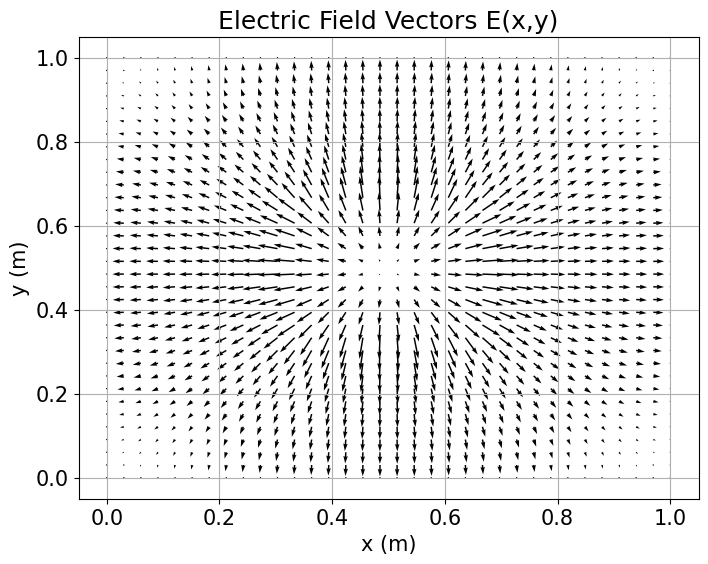

In [25]:
ll = 1.0     # size of square (m)
nn = 100     # grid pts on each edge
tolerance = 1e-6
omega = 0.9

a = ll / (nn-1)   # grid spacing
phi = np.zeros((nn, nn))

rho0 = 1e6  
rho = np.zeros((nn, nn))

# rho
for i in range(nn):
    for j in range(nn):
        x = i * a
        y = j * a
        if ll/3 < x < 2*ll/3 and ll/3 < y < 2*ll/3:
            rho[i,j] = rho0

# set V on boundaries
for i in range(nn):
    phi[i,0] = 0.0      # left edge
    phi[i,nn-1] = 0.0     # right edge
for j in range(nn):
    phi[0,j] = 0.0      # bottom edge
    phi[nn-1,j] = 0.0     # top edge

# Relaxation
deltaphimax = 2 * tolerance
sweeps = 0
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0
    for j in range(1, nn-1):
        for k in range(1, nn-1):
            phinew = 0.25 * ((phi[j+1,k] + phi[j-1,k] + phi[j,k+1] + phi[j,k-1]) + a*a*rho[j,k])
            deltaphi = (1 + omega) * (phinew - phi[j,k])
            phi[j,k] += deltaphi
            if abs(deltaphi) > deltaphimax:
                deltaphimax = abs(deltaphi)

print('Sweeps =', sweeps, '   Biggest dV =', deltaphimax, 'V')
print(f'Center voltage = {phi[int(nn/2), int(nn/2)]} V')

Ex = np.zeros_like(phi)
Ey = np.zeros_like(phi)

for j in range(1, nn-1):
    for k in range(1, nn-1):
        Ex[j,k] = -(phi[j,k+1] - phi[j,k-1]) / (2*a)  
        Ey[j,k] = -(phi[j+1,k] - phi[j-1,k]) / (2*a)  

# Plotting
X = np.linspace(0, ll, nn)
Y = np.linspace(0, ll, nn)
X, Y = np.meshgrid(X, Y)

dec = 3 # decimation factor
EX2 = Ex[::dec,::dec]
EY2 = Ey[::dec,::dec]
X2 = X[::dec,::dec]
Y2 = Y[::dec,::dec]

plt.rc('font', size=15)
plt.figure(figsize=(8,6))
plt.quiver(X2,Y2,EX2,EY2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Electric Field Vectors E(x,y)')
plt.grid(True)
plt.show()

5. Newman Ex. 9.3: Parallel-plate capacitor. Consider the follow-
ing simple two-dimensional model of an electronic capacitor, consisting

of two flat metal plates enclosed in a square metal box:

Using any of the methods we have studied, write a program to calculate
the electrostatic potential in the box on a grid of 100×100 points, where
the walls of the box are at voltage zero and the two plates (which are
of negligible thickness) are at voltages ±1 V as shown.

(a) (15 points) Have your program calculate the value of the potential
at each grid point to a precision of 10−6 volts and then make a
density plot of the result.

(b) (10 points) Plot the equipotentials

(c) (10 points) Plot the electric field lines, using the techniques from
the previous two problems.

Sweeps = 251    Biggest dV = 9.624019450815702e-07 V
Center voltage = -0.031693082423567207 V


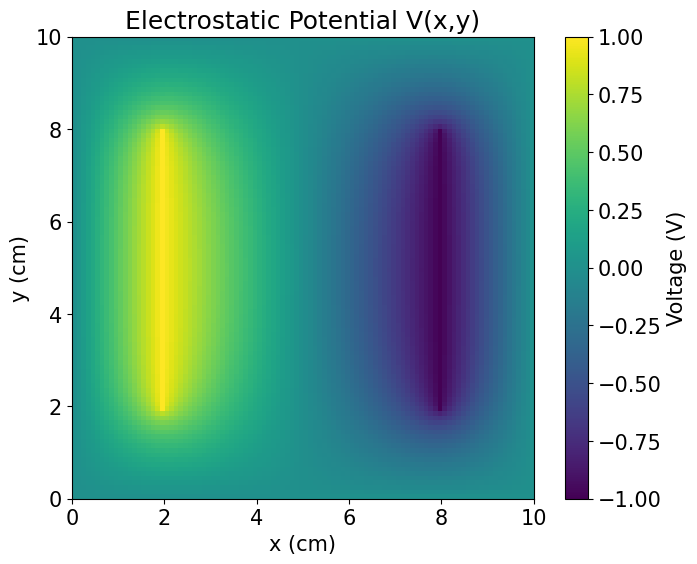

In [34]:
ll = 1.0     # size of square (m)
nn = 100     # grid pts on each edge
tolerance = 1e-6
omega = 0.9

a = ll / (nn-1)   # grid spacing
phi = np.zeros((nn, nn))

# set V on boundaries
for i in range(nn):
    phi[i,0] = 0.0      # left edge
    phi[i,nn-1] = 0.0     # right edge
for j in range(nn):
    phi[0,j] = 0.0      # bottom edge
    phi[nn-1,j] = 0.0     # top edge

x_plate_pos_1 = int(0.2 * (nn-1))   
x_plate_pos_2 = int(0.8 * (nn-1))    

y_start = int(0.2 * (nn-1))          
y_end = int(0.8 * (nn-1))          

for j in range(y_start, y_end+1):
    phi[j, x_plate_pos_1] = 1.0    
    phi[j, x_plate_pos_2] = -1.0  

# relaxation calculation
deltaphimax = 2*tolerance  # initialize bigger than tolerance
sweeps = 0      # keep track of number of iterations before convergence
while deltaphimax > tolerance:
    sweeps += 1
    deltaphimax = 0.0    
    for j in range(1,nn-1):
        for k in range(1,nn-1):
            if (k == x_plate_pos_1 and y_start <= j <= y_end) or (k == x_plate_pos_2 and y_start <= j <= y_end):
                continue
            phinew = 0.25*(phi[j+1,k]+phi[j-1,k]+phi[j,k+1]+phi[j,k-1]) 
            deltaphi = (1+omega)*(phinew - phi[j,k]) 
            phi[j,k] += deltaphi       
            if abs(deltaphi) > deltaphimax:    
                deltaphimax = abs(deltaphi)

print('Sweeps =', sweeps, '   Biggest dV =', deltaphimax, 'V')
print(f'Center voltage = {phi[int(nn/2), int(nn/2)]} V')

# plot result
plt.rc('font',size=15)
plt.figure(figsize=(8,6))
plt.imshow(phi, origin='lower', extent=(0,10,0,10)) 
plt.colorbar(label='Voltage (V)')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.title('Electrostatic Potential V(x,y)')
plt.show()
